# Dataloading speed vs. fit time

In [1]:
from torch.utils.data import DataLoader
import time

import torch
import pytorch_lightning as pl
import numpy as np
import pandas as pd

from mock_dataset import MockDataset
from models import SimpleLinearModel, SCVI

torch.set_float32_matmul_precision("high")

In [2]:
INPUT_DIM = 20000
N_CLASSES = 100
BATCH_SIZE = 32768


def create_loader(batch_size, sleep_time):
    return DataLoader(
        MockDataset(
            batch_size,
            sleep_time,
            INPUT_DIM,
            N_CLASSES,
            7,
        ),
        batch_size=None,
    )


def train_model(model):
    res = {"sleep": [], "fit_time": []}

    for sleep in 4. * np.logspace(1, -3, 8):
        trainer = pl.Trainer(
            max_epochs=1,
            logger=False,
            enable_model_summary=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
        )
        start = time.time()
        trainer.fit(model, train_dataloaders=create_loader(BATCH_SIZE, sleep))
        res["fit_time"].append(time.time() - start)
        res["sleep"].append(sleep)

    return pd.DataFrame(res)


In [3]:
res_linear = train_model(
    SimpleLinearModel(input_dim=INPUT_DIM, num_classes=N_CLASSES)
)

/vol/data/miniconda3/envs/merlin-2312/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/vol/data/miniconda3/envs/merlin-2312/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


In [5]:
res_scvi = train_model(
    SCVI(
        input_dim=INPUT_DIM,
        hidden_dims=[128, 128],
        latent_dim=50,
        lr=1e-3,
        weight_decay=1e-6,
        beta=1.0,
        dropout=0.,
    )
)

In [6]:
res_scvi_big = train_model(
    SCVI(
        input_dim=INPUT_DIM,
        hidden_dims=[1024, 1024, 1024, 1024],
        latent_dim=50,
        lr=1e-3,
        weight_decay=1e-6,
        beta=1.0,
        dropout=0.,
    )
)

In [7]:
def benchmark(loader, n_samples, batch_size):
    num_iter = n_samples // batch_size
    loader_iter = loader.__iter__()

    start_time = time.time()
    batch_times = []
    batch_time = time.time()
    for i, _batch in enumerate(loader_iter):
        batch_times.append(time.time() - batch_time)
        batch_time = time.time()
        if i == num_iter:
            break

    execution_time = time.time() - start_time
    time_per_sample = (1e6 * execution_time) / (num_iter * batch_size)
    print(f"time per sample: {time_per_sample:.2f} μs")
    samples_per_sec = num_iter * batch_size / execution_time
    print(f"samples per sec: {samples_per_sec:.2f} samples/sec")

    return samples_per_sec, time_per_sample, batch_times


In [9]:
samples_per_sec = []

for sleep_time in res_linear.sleep:
    samples_per_sec.append(
        benchmark(create_loader(BATCH_SIZE, sleep_time), BATCH_SIZE * 7, BATCH_SIZE)[0]
    )

res_linear["samples_per_sec"] = samples_per_sec
res_scvi["samples_per_sec"] = samples_per_sec
res_scvi_big["samples_per_sec"] = samples_per_sec

time per sample: 1221.90 μs
samples per sec: 818.39 samples/sec
time per sample: 327.78 μs
samples per sec: 3050.84 samples/sec
time per sample: 87.95 μs
samples per sec: 11370.06 samples/sec
time per sample: 23.60 μs
samples per sec: 42373.24 samples/sec
time per sample: 6.34 μs
samples per sec: 157832.83 samples/sec
time per sample: 1.70 μs
samples per sec: 587058.16 samples/sec
time per sample: 0.46 μs
samples per sec: 2173684.31 samples/sec
time per sample: 0.13 μs
samples per sec: 7921423.07 samples/sec


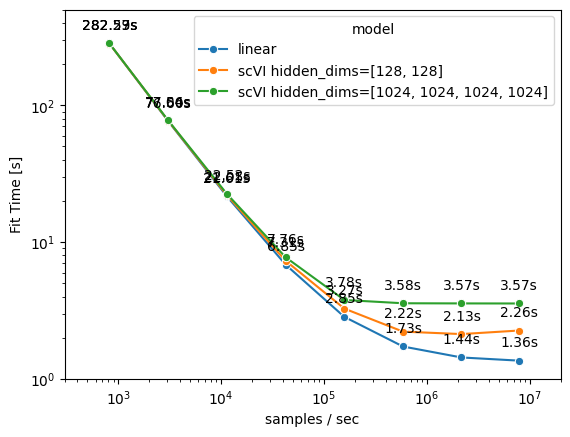

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


results = pd.concat([
    res_linear.assign(model="linear"),
    res_scvi.assign(model="scVI hidden_dims=[128, 128]"),
    res_scvi_big.assign(model="scVI hidden_dims=[1024, 1024, 1024, 1024]")
])


ax = sns.lineplot(results, x="samples_per_sec", y="fit_time", marker="o", hue="model")
ax.set_ylabel("Fit Time [s]")
ax.set_xlabel("samples / sec")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlim(300, 2. * 1e7)
ax.set_ylim(1, 500)

for i, row in results.iterrows():
    ax.annotate(f'{row["fit_time"]:.2f}s', 
                (row["samples_per_sec"], row["fit_time"]),
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center')

plt.savefig("fit_time.png", dpi=300, bbox_inches='tight')
plt.savefig("fit_time.svg", dpi=300, bbox_inches='tight')

In [12]:
results.to_csv("fit_time_vs_loading_speed.csv")

In [14]:
4. * np.logspace(1, -3, 8)

array([4.00000000e+01, 1.07307832e+01, 2.87874269e+00, 7.72279092e-01,
       2.07178987e-01, 5.55798198e-02, 1.49103749e-02, 4.00000000e-03])

In [15]:
7.72279092e-01

0.772279092